In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
current_pwd = os.getcwd()

possible_paths = [
    '/home/export/soheuny/SRFinder/soheun/notebooks', 
    '/home/soheuny/HH4bsim/soheun/notebooks'
]
    
assert os.getcwd() in possible_paths, f"Did you change the path? It should be one of {possible_paths}"
os.chdir("..")

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from plots import hist_events_by_labels
from events_data import EventsData
from fvt_classifier import FvTClassifier
# import LogNorm
from matplotlib.colors import LogNorm
from training_info import TrainingInfo
from plots import plot_rewighted_samples_by_model, plot_samples_raw
from dataset import MotherSamples
from events_data import events_from_scdinfo
import pickle

features = [
    "sym_Jet0_pt", "sym_Jet1_pt", "sym_Jet2_pt", "sym_Jet3_pt",
    "sym_Jet0_eta", "sym_Jet1_eta", "sym_Jet2_eta", "sym_Jet3_eta",
    "sym_Jet0_phi", "sym_Jet1_phi", "sym_Jet2_phi", "sym_Jet3_phi",  
    "sym_Jet0_m", "sym_Jet1_m", "sym_Jet2_m", "sym_Jet3_m",
]

# use tex
plt.rcParams["text.usetex"] = True
# plt.rcParams["font.family"] = "serif"
# plt.rcParams["font.serif"] = "Times New Roman"

plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.titlesize"] = 20
plt.rcParams["axes.titlesize"] = 20
plt.rcParams["axes.labelsize"] = 15
plt.rcParams["figure.labelsize"] = 20
plt.rcParams["lines.markersize"] = 3

import pandas as pd

In [3]:
no_signal_filter = {
    "dataset": lambda x: (
        x["n_3b"] == 100_0000, 
        x["ratio_4b"] == 0.5,
        x["signal_filename"] == "HH4b_picoAOD.h5",
        x["signal_ratio"] == 0.0,
    ), 
    "experiment_name": "CR_fvt_training_ensemble_max"
}
hashes = TrainingInfo.find(no_signal_filter)

In [8]:
metadata = TrainingInfo.load_cached_metadata()

pull_dict = {}
for experiment_name in ["CR_fvt_training_ensemble_max_HH4b_400", 
                        "CR_fvt_training_ensemble_max"]:
    pull_dict_a = pickle.load(open(f"./data/pulls/pull_by_hashes_sr_stats_{experiment_name}.pkl", "rb"))
    pull_dict.update(pull_dict_a)
    
no_signal_filter = {
    "dataset": lambda x: (
        x["n_3b"] == 100_0000, 
        x["ratio_4b"] == 0.5,
        x["signal_filename"] == "HH4b_picoAOD.h5",
        x["signal_ratio"] == 0.0,
    ), 
    "experiment_name": "CR_fvt_training_ensemble_max"
}
hashes = TrainingInfo.find(no_signal_filter)

hh4b_400_filter = {
    "dataset": lambda x: (
        x["n_3b"] == 100_0000, 
        x["ratio_4b"] == 0.5,
        x["signal_filename"] == "HH4b_400.h5",
    ), 
    "experiment_name": "CR_fvt_training_ensemble_max_HH4b_400"
}
hashes_hh4b_400 = TrainingInfo.find(hh4b_400_filter)
hashes = hashes_hh4b_400 + hashes

corrupted_hashes = []

for hash in pull_dict:
    if hash not in hashes:
        continue
    try:
        hparams = metadata[hash]
        signal_ratio = hparams["dataset"]["signal_ratio"]
        SR_size = hparams["signal_region"]["4b_in_SR"]    
        sr_stats_hash = hparams["signal_region"]["SR_stats_hashes"][0]
        sr_stats_type = hparams["signal_region"]["stats_type"]
        if sr_stats_type == "fvt":
            noise_scale = np.inf
        else:
            noise_scale = metadata[sr_stats_hash]["smearing"]["noise_scale"]
    
        for v in pull_dict[hash]:
            binning_mode = v["binning_mode"]
            nbins = v["nbins"]
            hists = v["hists"]
            hist_3b_rw = hists["3b_rw"]
            hist_3b_rw_sq = hists["3b_rw_sq"]
            hist_4b = hists["4b"]
            hist_4b_sq = hists["4b_sq"]
            var_o1 = hists["var_o1"]
            var_o2 = hists["var_o2"]
            var_o3 = hists["var_o3"]
            hist_3b_o1 = hists["3b_corrected_o1"]
            hist_3b_o2 = hists["3b_corrected_o2"]
            hist_3b_o3 = hists["3b_corrected_o3"]
            hist_signal = hists["signal"]
            hist_bg4b = hists["bg4b"]
            
            if binning_mode == "train":
                var_o0 = hist_4b_sq + hist_3b_rw_sq
            else:
                var_o0 = hist_4b_sq + hist_3b_rw_sq / nbins**2

            v["signal_ratio"] = signal_ratio
            v["SR_size"] = SR_size
            v["noise_scale"] = noise_scale
            v["pull_o0"] = (hist_4b - hist_3b_rw) / np.sqrt(var_o0)
            v["pull_o1"] = (hist_4b - hist_3b_o1) / np.sqrt(var_o1)
            v["pull_o2"] = (hist_4b - hist_3b_o2) / np.sqrt(var_o2)
            v["pull_o3"] = (hist_4b - hist_3b_o3) / np.sqrt(var_o3)
            v["pull_signal"] = hist_signal / np.sqrt(var_o0)
            v["pull_bg4b"] = (hist_bg4b - hist_3b_rw) / np.sqrt(var_o0)
            
    except:
        print(f"Corrupted hash: {hash}")
        corrupted_hashes.append(hash)
        continue


/tmp/user/3393/ipykernel_765834/3446700672.py:72: RuntimeWarning: invalid value encountered in divide
  v["pull_o0"] = (hist_4b - hist_3b_rw) / np.sqrt(var_o0)
/tmp/user/3393/ipykernel_765834/3446700672.py:76: RuntimeWarning: invalid value encountered in divide
  v["pull_signal"] = hist_signal / np.sqrt(var_o0)
/tmp/user/3393/ipykernel_765834/3446700672.py:77: RuntimeWarning: invalid value encountered in divide
  v["pull_bg4b"] = (hist_bg4b - hist_3b_rw) / np.sqrt(var_o0)
/tmp/user/3393/ipykernel_765834/3446700672.py:73: RuntimeWarning: invalid value encountered in divide
  v["pull_o1"] = (hist_4b - hist_3b_o1) / np.sqrt(var_o1)
/tmp/user/3393/ipykernel_765834/3446700672.py:74: RuntimeWarning: invalid value encountered in divide
  v["pull_o2"] = (hist_4b - hist_3b_o2) / np.sqrt(var_o2)
/tmp/user/3393/ipykernel_765834/3446700672.py:75: RuntimeWarning: invalid value encountered in divide
  v["pull_o3"] = (hist_4b - hist_3b_o3) / np.sqrt(var_o3)


In [9]:
nbins_list = [16, 32, 64]
pull_dict_as_list = []
for k, d in pull_dict.items():
    if k in corrupted_hashes:
        continue
    pull_dict_as_list.extend(d)

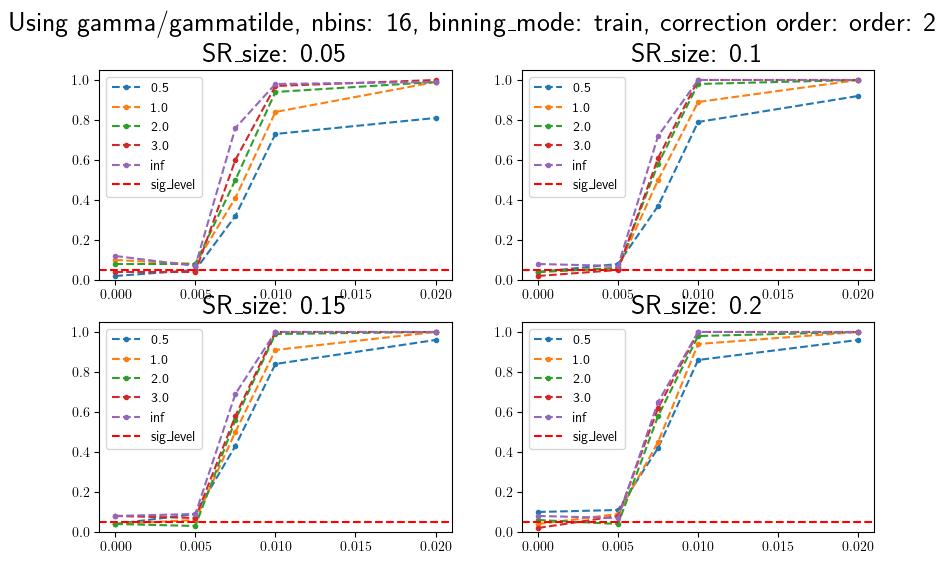

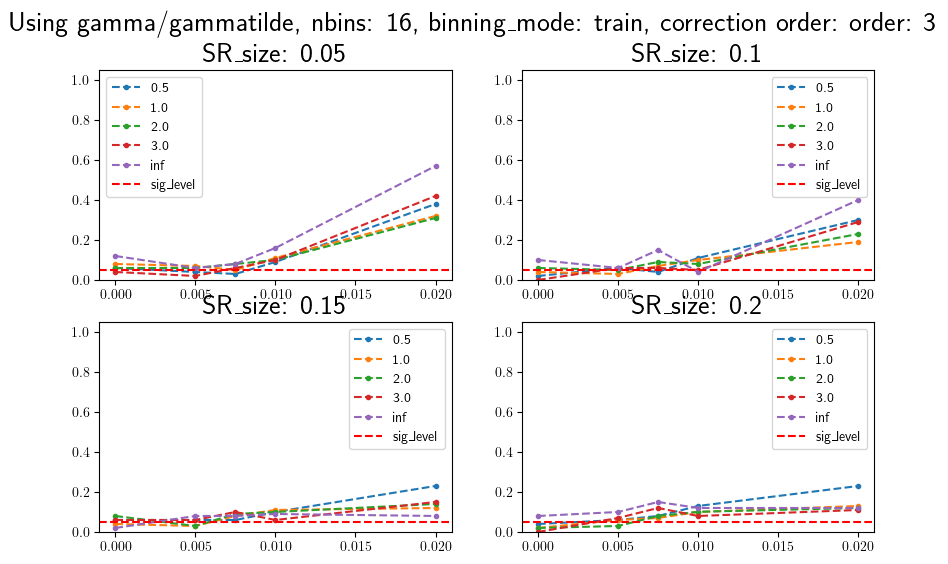

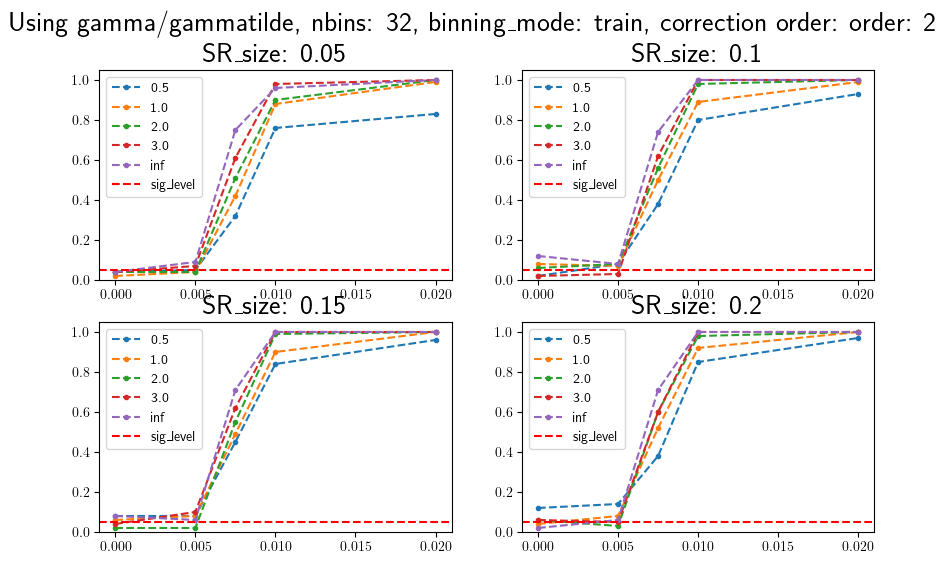

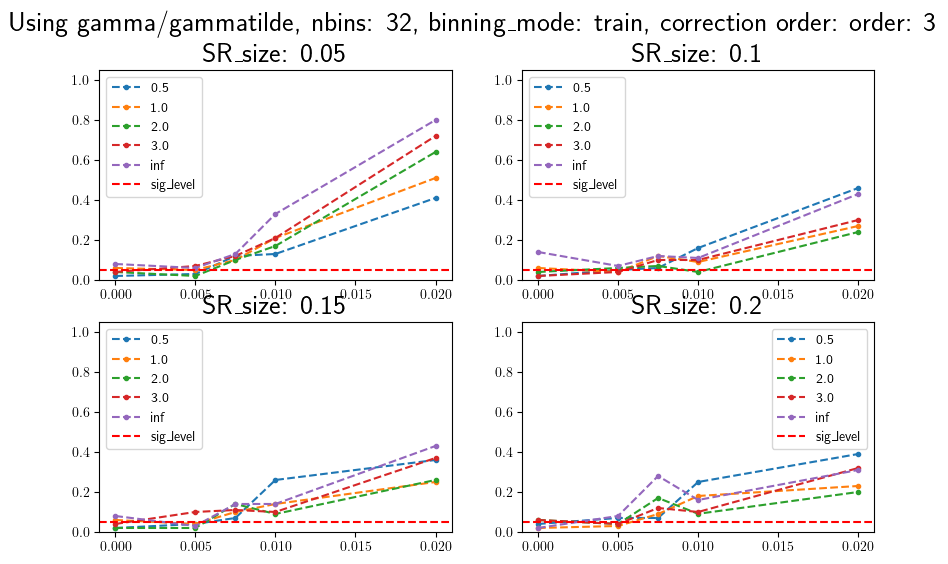

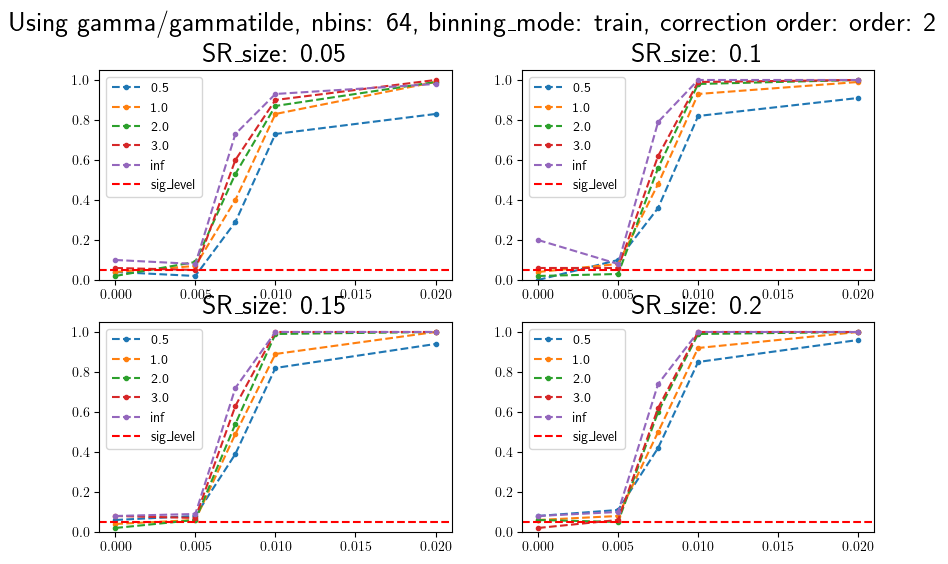

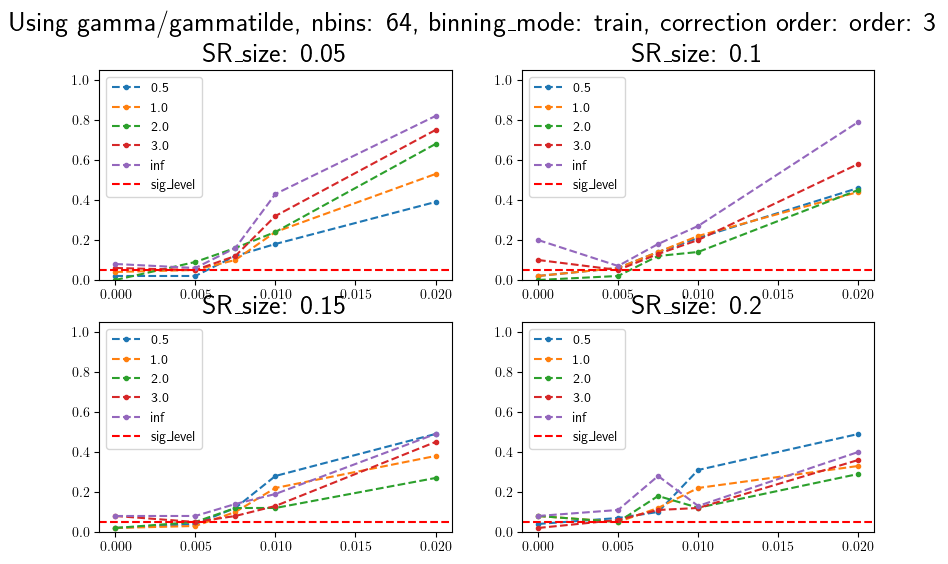

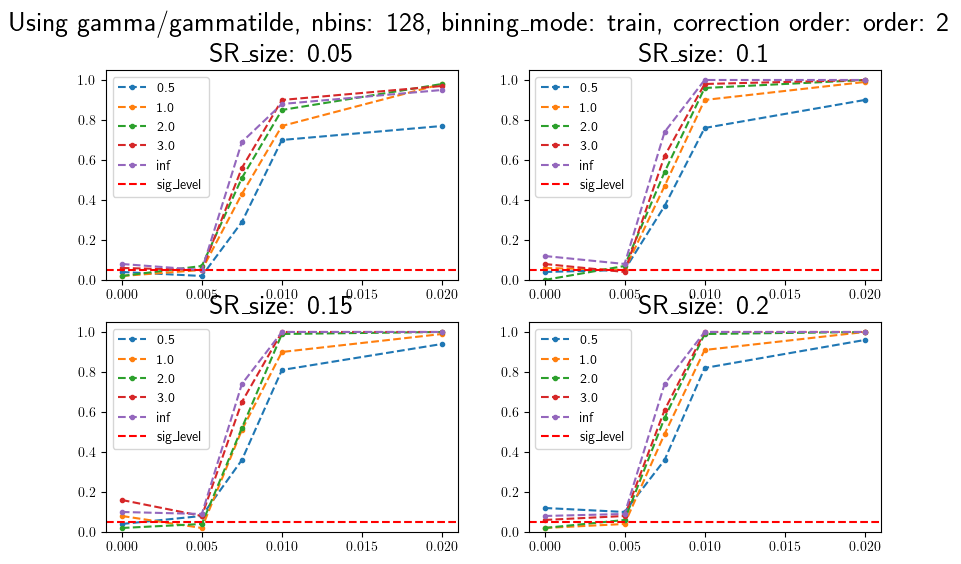

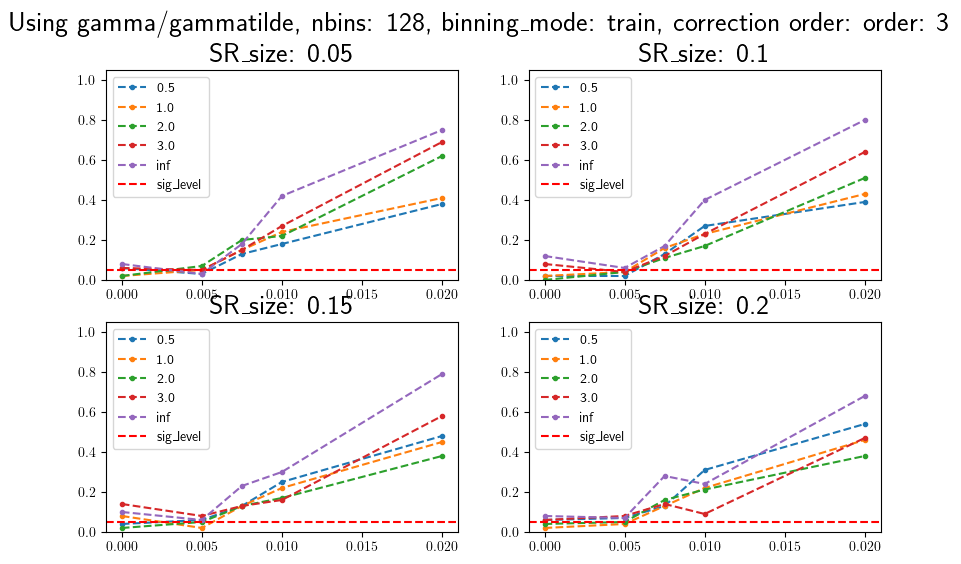

In [11]:
pull_df = pd.DataFrame([
    {"mean_pull_o0": np.sqrt(np.mean(v["pull_o0"]**2)), 
     "mean_pull_o1": np.sqrt(np.mean(v["pull_o1"]**2)), 
     "mean_pull_o2": np.sqrt(np.mean(v["pull_o2"]**2)), 
     "mean_pull_o3": np.sqrt(np.mean(v["pull_o3"]**2)),
     "binning_mode": v["binning_mode"],
     "nbins": v["nbins"], 
     "SR_size": v["SR_size"], 
     "signal_ratio": v["signal_ratio"], 
     "noise_scale": v["noise_scale"]} for v in pull_dict_as_list])

from scipy.stats import chi2
sig_level = 0.05
pull_df["rej_o0"] = (chi2.ppf(1 - sig_level, df=pull_df["nbins"]) / pull_df["nbins"])**0.5
pull_df["rej_o1"] = (chi2.ppf(1 - sig_level, df=pull_df["nbins"] - 1) / pull_df["nbins"])**0.5
pull_df["rej_o2"] = (chi2.ppf(1 - sig_level, df=pull_df["nbins"] - 2) / pull_df["nbins"])**0.5
pull_df["rej_o3"] = (chi2.ppf(1 - sig_level, df=pull_df["nbins"] - 3) / pull_df["nbins"])**0.5
pull_df["rejected_o0"] = pull_df["mean_pull_o0"] > pull_df["rej_o0"]
pull_df["rejected_o1"] = pull_df["mean_pull_o1"] > pull_df["rej_o1"]
pull_df["rejected_o2"] = pull_df["mean_pull_o2"] > pull_df["rej_o2"]
pull_df["rejected_o3"] = pull_df["mean_pull_o3"] > pull_df["rej_o3"]
pull_df_summary = pull_df.groupby(["SR_size", "signal_ratio", "nbins", "binning_mode", "noise_scale"]).mean().reset_index()


for nbins in [16, 32, 64, 128]:
    for binning_mode in ["train"]:
        # for noise_scale in [0.5, 1.0, 1.5, 2.0]:
        for correction_order, label in [
            # ("rejected_o0", "order: 0"), 
            #                     ("rejected_o1", "order: 1"), 
                                ("rejected_o2", "order: 2"),
                                ("rejected_o3", "order: 3")
                                ]:
            fig, ax = plt.subplots(2, 2, figsize=(10, 6))
            fig.suptitle(f"Using gamma/gammatilde, nbins: {nbins}, binning_mode: {binning_mode}, correction order: {label}")
            colors = plt.get_cmap("tab10").colors
            for ax_idx, SR_size in enumerate([0.05, 0.1, 0.15, 0.2]):
                current_ax = ax[ax_idx // 2, ax_idx % 2]
                current_ax.set_title(f"SR_size: {SR_size}")

                for i, noise_scale in enumerate([0.5, 1.0, 2.0, 3.0, np.inf]):
                    pull_df_nbins = pull_df_summary[(pull_df_summary["SR_size"] == SR_size) 
                                                    & (pull_df_summary["nbins"] == nbins)
                                                    & (pull_df_summary["binning_mode"] == binning_mode)
                                                    & (pull_df_summary["noise_scale"] == noise_scale)
                                                    ]
                    current_ax.plot(pull_df_nbins["signal_ratio"], 
                                pull_df_nbins[correction_order], 
                                label=noise_scale, 
                                color=colors[i],
                                linestyle="--",
                                marker="o")
                    i += 1
                current_ax.axhline(y=sig_level, color="red", linestyle="--", label="sig_level")
                current_ax.set_ylim(0, 1.05)
                current_ax.legend()
            plt.show()